<a href="https://colab.research.google.com/github/nutof-pefoce/forensicRT/blob/main/notebooks/rt_ods_attentiveFPmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit deepchem==2.5.0
!pip install --pre dgl -f https://data.dgl.ai/wheels-test/torch-2.4/repo.html
!pip install dgllife optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 15.8 MB/s eta 0:00:00
Looking in links: https://data.dgl.ai/wheels-test/torch-2.4/repo.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/ML/'

Mounted at /content/drive


###Preparing dependencies

In [ ]:
import os
os.environ['DGLBACKEND'] = 'pytorch'
import random
import pandas as pd
import numpy as np
import dgl
import torch
import deepchem as dc
from deepchem.feat import MolGraphConvFeaturizer
from deepchem.models import AttentiveFPModel
from deepchem.models.optimizers import Adam, ExponentialDecay
from deepchem.models.callbacks import ValidationCallback
from sklearn.model_selection import train_test_split
from deepchem.metrics import Metric
from sklearn.metrics import mean_absolute_error, r2_score
import optuna

In [ ]:
# Setting the random seed for various libraries (NumPy, PyTorch, and Python's random module)
seed = 42
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)

###Preparing datasets

In [ ]:
df = pd.read_csv(data_dir + 'rt-ods_smiles.csv')
df

,SMILES,RT
0,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCC(C)C(=O)NCCF,8.628
1,CC(O)CCCn1cc(C(=O)C2C(C)(C)C2(C)C)c2ccccc21,7.199
2,CC(C)[C@H](NC(=O)c1cn(CC2CCCCC2)c2ccccc12)C(N)=O,7.596
3,CC(C)[C@H](NC(=O)c1cn(CC2CCCCC2)c2ccccc12)C(N)=O,7.596
4,c1ccc(C(c2ccccc2)[C@@H]2CCCN2)cc1,4.769
...,...,...
560,CCC(F)CCn1cc(C(=O)C2C(C)(C)C2(C)C)c2ccccc21,7.685
561,CCC(F)CCn1cc(C(=O)C2C(C)(C)C2(C)C)c2ccccc21,7.692
562,C=CCCCn1cc(C(=O)C2C(C)(C)C2(C)C)c2ccccc21,7.946
563,C=C(C)C(C)(C)CC(=O)c1cn(CCCCCF)c2ccccc12,7.517


In [ ]:
# Define the featurizer
featurizer = MolGraphConvFeaturizer(use_edges=True)

# Access data from the pandas DataFrame *before* creating the DeepChem dataset
smiles_list = df['SMILES'].to_numpy()
feature_list = featurizer.featurize(smiles_list)
target_values = df[['RT']].to_numpy()

g_train_opt, g_val_test, rt_train_opt, rt_val_test = train_test_split(
    feature_list, target_values, train_size=0.70, random_state=42)

g_train, g_opt, rt_train, rt_opt = train_test_split(
    g_train_opt, rt_train_opt, train_size=(0.55/0.70), shuffle=False)

g_val, g_test, rt_val, rt_test = train_test_split(
    g_val_test, rt_val_test, test_size=0.5, shuffle=False)

# Create DeepChem datasets

train_dataset = dc.data.NumpyDataset(X=g_train, y=rt_train)
optim_dataset = dc.data.NumpyDataset(X=g_opt, y=rt_opt)
valid_dataset = dc.data.NumpyDataset(X=g_val, y=rt_val)
test_dataset = dc.data.NumpyDataset(X=g_test, y=rt_test)

datasets = {
    "train": train_dataset,
    "optim": optim_dataset,
    "valid": valid_dataset,
    "test": test_dataset
}

In [ ]:
print("Number of train samples: ", train_dataset.X.shape[0])
print("Number of optim samples: ", optim_dataset.X.shape[0])
print("Number of valid samples: ", valid_dataset.X.shape[0])
print("Number of test samples: ", test_dataset.X.shape[0])
print("Number of tasks: ", train_dataset.y.shape[1])

Number of train samples:  310
Number of optim samples:  85
Number of valid samples:  85
Number of test samples:  85
Number of tasks:  1


###Model optimisation

In [ ]:
mae = Metric(mean_absolute_error)
r2 = Metric(r2_score)
metrics = [mae, r2]

In [ ]:
model = AttentiveFPModel(mode='regression', n_tasks=1, num_layers=1, num_timesteps=2, graph_feat_size=200, dropout=0.0,
                         batch_size=8, learning_rate=0.001, weight_decay=1e-6)

loss = model.fit(train_dataset, nb_epoch=40, callbacks=ValidationCallback(optim_dataset, 100, metrics))

train_scores = model.evaluate(train_dataset, metrics)
valid_scores = model.evaluate(valid_dataset, metrics)

print("Train scores")
print(f"Train MAE = {train_scores[mae.name]:.3f}") # Access using mae.name
print(f"Train R2 = {train_scores[r2.name]:.3f}")   # Access using r2.name

print("Validation scores")
print(f"Validation MAE = {valid_scores[mae.name]:.3f}") # Access using mae.name
print(f"Validation R2 = {valid_scores[r2.name]:.3f}")   # Access using r2.name

Step 100 validation: mean_absolute_error=0.725965 r2_score=0.783412
Step 200 validation: mean_absolute_error=0.597081 r2_score=0.856627
Step 300 validation: mean_absolute_error=0.496788 r2_score=0.879862
Step 400 validation: mean_absolute_error=0.508606 r2_score=0.880863
Step 500 validation: mean_absolute_error=0.477741 r2_score=0.885468
Step 600 validation: mean_absolute_error=0.478753 r2_score=0.895835
Step 700 validation: mean_absolute_error=0.446354 r2_score=0.897285
Step 800 validation: mean_absolute_error=0.483583 r2_score=0.892495
Step 900 validation: mean_absolute_error=0.543895 r2_score=0.871015
Step 1000 validation: mean_absolute_error=0.570966 r2_score=0.867359
Step 1100 validation: mean_absolute_error=0.547391 r2_score=0.874456
Step 1200 validation: mean_absolute_error=0.435337 r2_score=0.899169
Step 1300 validation: mean_absolute_error=0.422735 r2_score=0.903136
Step 1400 validation: mean_absolute_error=0.484663 r2_score=0.890949
Step 1500 validation: mean_absolute_error=0

In [ ]:
def objective(trial):

  dropout = trial.suggest_float('dropout', 0.00, 0.50, step=0.01)
  graph_feat_size = trial.suggest_int('graph_feat_size', 100, 300)
  learning_rate = trial.suggest_float('initial_rate', 0.0001, 0.01, log=True)
  weight_decay = trial.suggest_float('weight_decay', 1e-7, 1e-5, log=True)

  model = AttentiveFPModel(mode='regression', n_tasks=1, num_layers=1, num_timesteps=2, graph_feat_size=graph_feat_size, dropout=dropout,
                         batch_size=8, learning_rate=learning_rate,
                         weight_decay=weight_decay)

  model.fit(train_dataset, nb_epoch=40, callbacks=ValidationCallback(optim_dataset, 2000, metrics))

  valid_scores = model.evaluate(valid_dataset, metrics)
  valid_loss = valid_scores[mae.name]

  return valid_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print(study.best_trial)

[I 2026-04-01 15:04:24,278] A new study created in memory with name: no-name-1128f586-6b05-40a4-b22e-cf0aa2ebd764
[I 2026-04-01 15:06:23,908] Trial 0 finished with value: 0.43147200905294975 and parameters: {'dropout': 0.45, 'graph_feat_size': 278, 'initial_rate': 0.0010249098809727228, 'weight_decay': 9.371530181210788e-07}. Best is trial 0 with value: 0.43147200905294975.
[I 2026-04-01 15:08:23,144] Trial 1 finished with value: 0.4221643169403076 and parameters: {'dropout': 0.07, 'graph_feat_size': 286, 'initial_rate': 0.00036505790628744246, 'weight_decay': 2.975783028311282e-06}. Best is trial 1 with value: 0.4221643169403076.
[I 2026-04-01 15:10:08,875] Trial 2 finished with value: 0.4849787719726564 and parameters: {'dropout': 0.38, 'graph_feat_size': 248, 'initial_rate': 0.001008851351427749, 'weight_decay': 8.118547558649024e-06}. Best is trial 1 with value: 0.4221643169403076.
[I 2026-04-01 15:11:15,096] Trial 3 finished with value: 0.5095678654951208 and parameters: {'dropout

FrozenTrial(number=19, state=<TrialState.COMPLETE: 1>, values=[0.3688382607179529], datetime_start=datetime.datetime(2026, 4, 1, 15, 30, 47, 578469), datetime_complete=datetime.datetime(2026, 4, 1, 15, 31, 58, 463030), params={'dropout': 0.0, 'graph_feat_size': 209, 'initial_rate': 0.0005698085549759554, 'weight_decay': 5.492069337349488e-07}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'dropout': FloatDistribution(high=0.5, log=False, low=0.0, step=0.01), 'graph_feat_size': IntDistribution(high=300, log=False, low=100, step=1), 'initial_rate': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'weight_decay': FloatDistribution(high=1e-05, log=True, low=1e-07, step=None)}, trial_id=19, value=None)


In [ ]:
import time

num_runs = 5
train_preds = []
valid_preds = []
test_preds = []

start_time = time.perf_counter()

for _ in range(num_runs):
    model = AttentiveFPModel(mode='regression', n_tasks=1, num_layers=1, num_timesteps=2, graph_feat_size=100, dropout=0.0,
                         batch_size=8, learning_rate=0.0024, weight_decay=3.16e-7)


    mae = Metric(mean_absolute_error)
    r2 = Metric(r2_score)
    metrics = [mae, r2]

    model.fit(train_dataset, nb_epoch=40, callbacks=ValidationCallback(optim_dataset, 2000, metrics))

    train_pred = model.predict(train_dataset)
    valid_pred = model.predict(valid_dataset)
    test_pred = model.predict(test_dataset)

    train_preds.append(train_pred)
    valid_preds.append(valid_pred)
    test_preds.append(test_pred)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
average_time_per_run = elapsed_time / num_runs

train_pred = np.mean(train_preds, axis=0)
val_pred = np.mean(valid_preds, axis=0)
test_pred = np.mean(test_preds, axis=0)

train_r_squared = r2_score(train_dataset.y, train_pred)
train_mae = mean_absolute_error(train_dataset.y, train_pred)

val_r_squared = r2_score(valid_dataset.y, val_pred)
val_mae = mean_absolute_error(valid_dataset.y, val_pred)

test_r_squared = r2_score(test_dataset.y, test_pred)
test_mae = mean_absolute_error(test_dataset.y, test_pred)

print(f"train R²: {train_r_squared:.3f}")
print(f"train MAE: {train_mae:.3f}")
print(f"validation R²: {val_r_squared:.3f}")
print(f"validation MAE: {val_mae:.3f}")
print(f"test R²: {test_r_squared:.3f}")
print(f"test MAE: {test_mae:.3f}")

print(f"Average time per run: {average_time_per_run:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/deepchem/models/torch_models/torch_model.py:391: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  avg_loss = float(avg_loss) / averaged_batches


train R²: 0.960
train MAE: 0.281
validation R²: 0.875
validation MAE: 0.509
test R²: 0.919
test MAE: 0.370
Average time per run: 52.33 seconds




```
train R²: 0.952
train MAE: 0.292
validation R²: 0.941
validation MAE: 0.367
test R²: 0.895
test MAE: 0.438
Average time per run: 48.90 seconds
```



In [ ]:
predictions = {
    "train": np.array(train_preds),
    "valid": np.array(valid_preds),
    "test": np.array(test_preds)
}

for dataset_name in predictions.keys():
    dataset = datasets[dataset_name] # Get the corresponding dataset from the original 'datasets' dict
    pred_list = []
    for i in range(num_runs):
        pred_run = pd.DataFrame(predictions[dataset_name][i].squeeze(), columns=[f'pred RT run {i+1}'])
        pred_list.append(pred_run)


    pred_df = pd.concat(pred_list, axis=1)
    pred_df['avg pred RT'] = pred_df.mean(axis=1)
    substance = pd.DataFrame(dataset.ids, columns=['Compound'])
    exp_rt = pd.DataFrame(dataset.y, columns=['exp RT'])
    predictions_df = pd.concat([substance, exp_rt, pred_df], axis=1)

    # Calculate the 'Error' column
    predictions_df['Error'] = predictions_df['avg pred RT'] - predictions_df['exp RT']

    # Define a function to classify errors into windows
    def classify_error(error):
        if error < -2:
            return '< -2 min'
        elif -2 <= error < -1:
            return '-2 to -1 min'
        elif -1 <= error < -0.5:
            return '-1 to -0.5 min'
        elif -0.5 <= error <= 0.5:
            return '± 0.5 min'
        elif 0.5 < error <= 1:
            return '0.5 to 1 min'
        elif 1 < error <= 2:
            return '1 to 2 min'
        else:
            return '> 2 min'

    # Apply the function to create the 'error window' column
    predictions_df['error window'] = predictions_df['Error'].apply(classify_error)

    display(predictions_df)  # Display the updated DataFrame
    print(f"Displaying the {dataset_name} dataset with predictions and error information.")

    #Save to CSV
    predictions_df.to_csv(data_dir + f"rt_ods_{dataset_name}_attFP_preds.csv", index=False)
    print(f'{dataset_name.capitalize()} predictions succesfully saved to csv.')

,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,0,7.085,7.676514,7.654494,7.110675,7.431131,7.305111,7.435585,0.350585,± 0.5 min
1,1,5.695,4.641988,4.964586,5.132629,5.066541,4.687073,4.898563,-0.796437,-1 to -0.5 min
2,2,4.790,5.381542,5.224040,4.997760,5.135566,5.033149,5.154411,0.364411,± 0.5 min
3,3,6.104,6.192665,6.727009,6.231526,7.036760,6.143175,6.466227,0.362227,± 0.5 min
4,4,2.701,2.693846,2.525715,2.521689,3.284499,2.433042,2.691759,-0.009241,± 0.5 min
...,...,...,...,...,...,...,...,...,...,...
305,305,7.611,7.807359,8.016901,7.678465,7.865803,7.694139,7.812533,0.201533,± 0.5 min
306,306,3.893,3.914538,4.422295,4.203995,4.659826,3.913496,4.222830,0.329830,± 0.5 min
307,307,3.768,3.946502,3.904417,3.837969,4.142154,3.779585,3.922126,0.154126,± 0.5 min
308,308,7.328,7.481700,7.320405,6.985230,7.404685,7.137033,7.265810,-0.062190,± 0.5 min


Displaying the train dataset with predictions and error information.
Train predictions succesfully saved to csv.


,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,0,4.158,3.716540,4.117138,3.784779,4.259779,3.406730,3.856993,-0.301007,± 0.5 min
1,1,5.054,4.577089,5.057537,4.920852,5.275314,4.570487,4.880256,-0.173744,± 0.5 min
2,2,7.253,5.865948,6.376605,6.004245,6.802844,6.033113,6.216551,-1.036449,-2 to -1 min
3,3,6.669,7.058736,7.412441,6.900429,7.522389,6.385107,7.055820,0.386820,± 0.5 min
4,4,7.633,8.311412,8.118164,7.648668,8.026517,7.814536,7.983860,0.350860,± 0.5 min
...,...,...,...,...,...,...,...,...,...,...
80,80,7.331,7.463881,7.733494,7.114572,7.399302,7.089782,7.360207,0.029207,± 0.5 min
81,81,3.116,3.484180,3.770311,3.682398,3.961509,3.329468,3.645573,0.529573,0.5 to 1 min
82,82,5.795,6.356616,7.169576,6.603657,7.034886,6.393916,6.711730,0.916730,0.5 to 1 min
83,83,3.290,3.273080,3.678349,3.453527,3.191181,2.746036,3.268435,-0.021565,± 0.5 min


Displaying the valid dataset with predictions and error information.
Valid predictions succesfully saved to csv.


,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,0,6.524,5.978741,6.278931,6.335945,6.500808,6.233503,6.265586,-0.258414,± 0.5 min
1,1,7.536,7.913129,7.742985,7.421232,7.904834,7.536465,7.703729,0.167729,± 0.5 min
2,2,6.047,6.147714,6.524582,6.104522,6.601037,5.851821,6.245935,0.198935,± 0.5 min
3,3,4.881,4.371879,4.313201,4.552016,4.578447,4.183748,4.399858,-0.481142,± 0.5 min
4,4,5.933,5.146177,5.765441,5.459385,5.634747,5.161509,5.433452,-0.499548,± 0.5 min
...,...,...,...,...,...,...,...,...,...,...
80,80,3.537,3.840675,4.327461,4.157323,4.602479,3.866198,4.158827,0.621827,0.5 to 1 min
81,81,8.933,8.461431,8.413332,8.098928,8.394600,8.185584,8.310776,-0.622224,-1 to -0.5 min
82,82,8.213,8.480523,8.207028,7.823596,8.430430,8.059889,8.200293,-0.012707,± 0.5 min
83,83,4.183,4.733201,4.975544,4.835997,5.249113,4.769630,4.912697,0.729697,0.5 to 1 min


Displaying the test dataset with predictions and error information.
Test predictions succesfully saved to csv.


###Model explicability and predictions

In [ ]:
model = AttentiveFPModel(mode='regression', n_tasks=1, num_layers=1, num_timesteps=2, graph_feat_size=100, dropout=0.0,
                         batch_size=8, learning_rate=0.0024, weight_decay=3.16e-7)

mae = Metric(mean_absolute_error)
r2 = Metric(r2_score)
metrics = [mae, r2]

model.fit(train_dataset, nb_epoch=40, callbacks=ValidationCallback(optim_dataset, 100, metrics))

valid_scores = model.evaluate(valid_dataset, metrics)
test_scores = model.evaluate(test_dataset, metrics)

print("Validation scores")
print(f"Validation MAE = {valid_scores[mae.name]:.3f}") # Access using mae.name
print(f"Validation R2 = {valid_scores[r2.name]:.3f}")   # Access using r2.name

print("Test scores")
print(f"Test MAE = {test_scores[mae.name]:.3f}") # Access using mae.name
print(f"Test R2 = {test_scores[r2.name]:.3f}")   # Access using r2.name

torch_model = model.model
gnn_model = torch_model.model

/usr/local/lib/python3.12/dist-packages/deepchem/models/torch_models/torch_model.py:391: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  avg_loss = float(avg_loss) / averaged_batches


Step 100 validation: mean_absolute_error=0.620169 r2_score=0.837438
Step 200 validation: mean_absolute_error=0.533568 r2_score=0.870682
Step 300 validation: mean_absolute_error=0.490752 r2_score=0.882315
Step 400 validation: mean_absolute_error=0.470326 r2_score=0.892252
Step 500 validation: mean_absolute_error=0.593737 r2_score=0.855329
Step 600 validation: mean_absolute_error=0.47498 r2_score=0.885811
Step 700 validation: mean_absolute_error=0.462326 r2_score=0.888795
Step 800 validation: mean_absolute_error=0.45019 r2_score=0.900093
Step 900 validation: mean_absolute_error=0.474294 r2_score=0.8857
Step 1000 validation: mean_absolute_error=0.591797 r2_score=0.858035
Step 1100 validation: mean_absolute_error=0.475311 r2_score=0.893833
Step 1200 validation: mean_absolute_error=0.554993 r2_score=0.86505
Step 1300 validation: mean_absolute_error=0.439501 r2_score=0.906241
Step 1400 validation: mean_absolute_error=0.546301 r2_score=0.871138
Step 1500 validation: mean_absolute_error=0.4464

In [ ]:
from IPython.display import SVG, display, Image
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdMolDescriptors
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D, SimilarityMaps
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [ ]:
def draw_similarity_map(smiles, dataset, timestep):

    # Extract SMILES and graph representation
    #smiles = dataset.ids[mol_id]
    #g = dataset.X[mol_id].to_dgl_graph()
    #g = dgl.batch([g])

    features = featurizer.featurize(smiles)
    g = features[0].to_dgl_graph()
    g = dgl.batch([g])

    # Get model outputs and attention weights
    atom_feats, bond_feats = g.ndata.pop('x'), g.edata.pop('edge_attr')
    _, atom_weights = gnn_model(g, atom_feats, bond_feats, get_node_weight=True)

    assert timestep < len(atom_weights), "timestep is too large"
    atom_weights = atom_weights[timestep] #.cpu().detach().numpy()  # Convert to numpy

    # Normalize the weights to -1, +1]
    min_value = torch.min(atom_weights)
    max_value = torch.max(atom_weights)
    atom_weights = (atom_weights - min_value) / (max_value - min_value)
    atom_weights = atom_weights * 2 - 1

    atom_weights_list = []

        # Convert SMILES to RDKit Mol object
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Invalid SMILES: {smiles}")
        return

    for i in range(g.number_of_nodes()):
        atom_weight = atom_weights[i].data.item()
        atom_weights_list.append(atom_weight)

    # Compute 2D coordinates
    #Chem.rdDepictor.Compute2DCoords(mol)
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)  # You can also use MolDraw2DSVG
    drawer.SetFontSize(1)

    # Generate Similarity Map
    contribs = SimilarityMaps.GetSimilarityMapFromWeights(mol, atom_weights_list, draw2d=drawer)
    drawer.FinishDrawing()
    png_file = 'similarity_map.png'
    contribs.WriteDrawingText(png_file)
    display(Image(filename=png_file))

    def predict_rt(smiles):
      sample_feats = featurizer.featurize(smiles)
      sample_pred = model.predict_on_batch(sample_feats)
      return sample_pred[0][0]

    sample_rt = predict_rt(smiles)
    print(f'Predited RT = {sample_rt:.3f}')

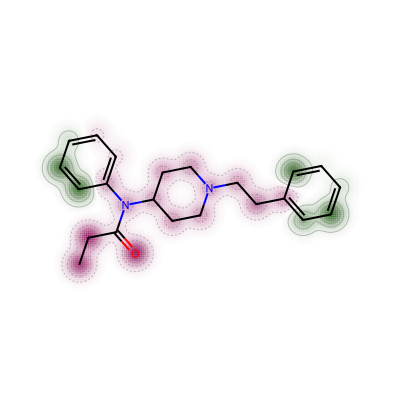

Predited RT = 6.129


In [ ]:
# Attention map for Fentanyl
draw_similarity_map('CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3', dataset, 1)

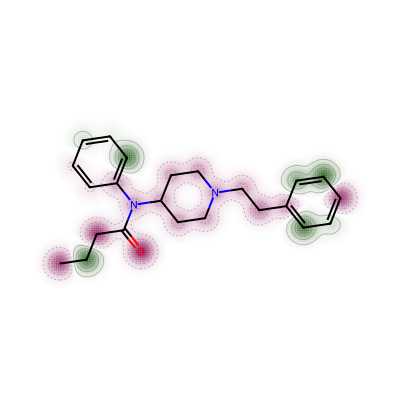

Predited RT = 6.413


In [ ]:
# Attention map for Butyryl-Fentanyl
draw_similarity_map('CCCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3', dataset, 1)

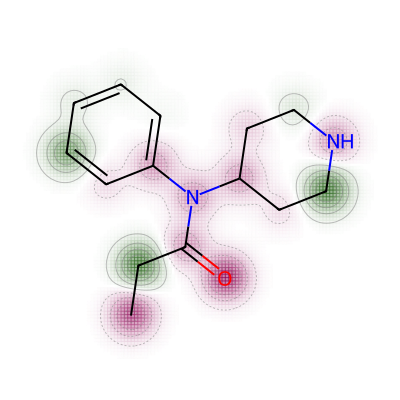

Predited RT = 4.658


In [ ]:
draw_similarity_map('CCC(=O)N(C1CCNCC1)C2=CC=CC=C2', dataset, 1)

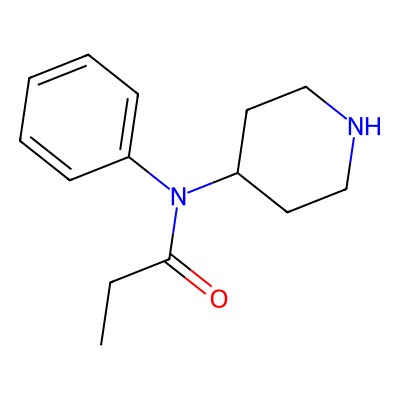

In [ ]:
# 1. Create the molecule object from a SMILES string
sample_mol = Chem.MolFromSmiles("CCC(=O)N(C1CCNCC1)C2=CC=CC=C2")

# 2. Generate the image
img = Draw.MolToImage(sample_mol, size=(400, 400))

# 3. Display or save the image
display(img)